In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
iris = load_iris()

import HelpfulFunctions as hp

### 1. Load iris data 

In [18]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
X.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


Define the target variable

In [23]:
y = iris.target
print(iris.target_names)
y

['setosa' 'versicolor' 'virginica']


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### 2. Feature space plot

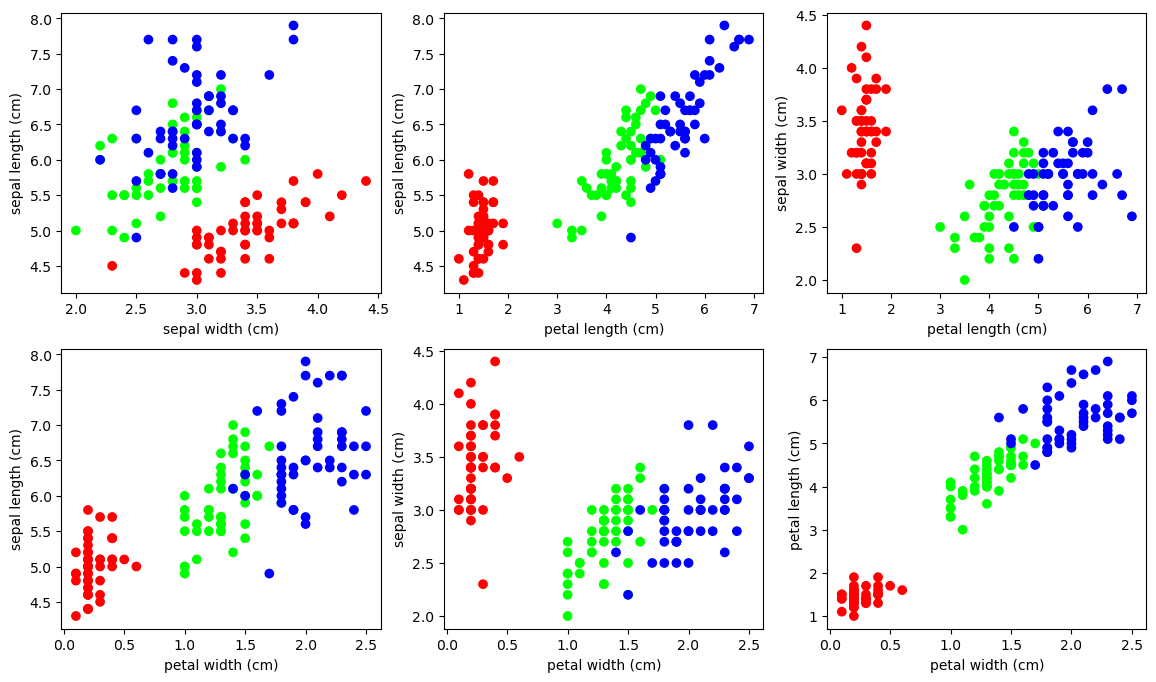

In [24]:
plt_idx = 1
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
plt.figure(figsize=(14, 8))

for index1 in range(0,4):
    for index2 in range(0,index1):
        f1 = X.columns[index1]
        f2 = X.columns[index2]
        x1 = X[f1]
        x2 = X[f2]
        plt.subplot(2,3,plt_idx)
        plt.scatter(x1,x2,c = y, cmap = cmap_bold)
        plt.xlabel(f1)
        plt.ylabel(f2)
        plt_idx = plt_idx+1

Separating 3 classes of Iris looks tough. Let's make it easier by focusing on a binary problem.

### 3. Case study

We wish to use Logistic Regression to determine whether a given Iris is a Virginica or not


* We first build a Model with One Feature

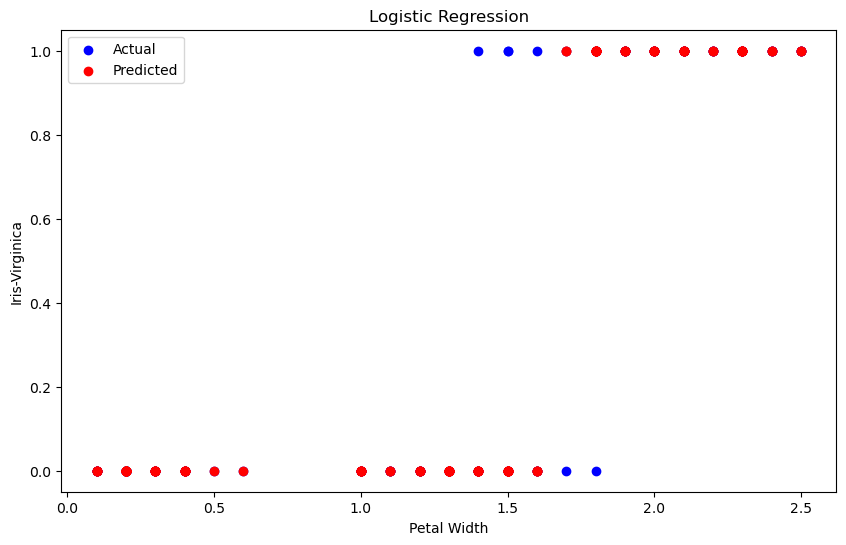

In [28]:
# We use one of the features to model the flower type 
X_1 = X['petal width (cm)']

X_1 = X_1.values.reshape(X.shape[0],1)
# We only want to predict if it is Iris-Virginica or not so we only consider the label to be 1 if y=2 and zero otherwise.
y_1 = (np.array(y)==2).astype(int)

# Fit the model 
log_reg = LogisticRegression(solver='liblinear')
log_reg.fit(X_1,y_1)

y_pred  = log_reg.predict(X_1)

# Plot the data points and the decision boundary
plt.figure(figsize=(10,6))
plt.scatter(X_1, y_1, color='blue', label='Actual')
plt.scatter(X_1, y_pred, color='red', label='Predicted')
plt.xlabel('Petal Width')
plt.ylabel('Iris-Virginica')
plt.title('Logistic Regression')
plt.legend()
plt.show()

In [29]:
y_1 - y_pred

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  1,  1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

-1 is a case where it is not virginica so prediction is incorrect - this happens 2 times

+1 is a case where it is virginica and the prediction is incorrect - this happens 4 times

* Now let's try using all four features at the same time.

In [ ]:
X_4 = X

log_reg = LogisticRegression(solver='liblinear')
log_reg.fit(X_4,y_1)
print(log_reg.coef_)
print(log_reg.intercept_)

y_pred_4  = log_reg.predict(X_4)
y_1 - y_pred_4  

[[-1.70751526 -1.53427768  2.47096755  2.55537041]]
[-1.21470917]


array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

-1 is a case where it is not virginica so prediction is incorrect - this happens 3 times

+1 is a case where it is virginica and the prediction is incorrect - this happens 0 times

Gone from 6 errors to 3 errors.

### 4. Visualize the feature space

We can see how the logistic regression splits the space of features into the different classification regions

We use sepal length and sepal width as features

c:\Users\33659\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


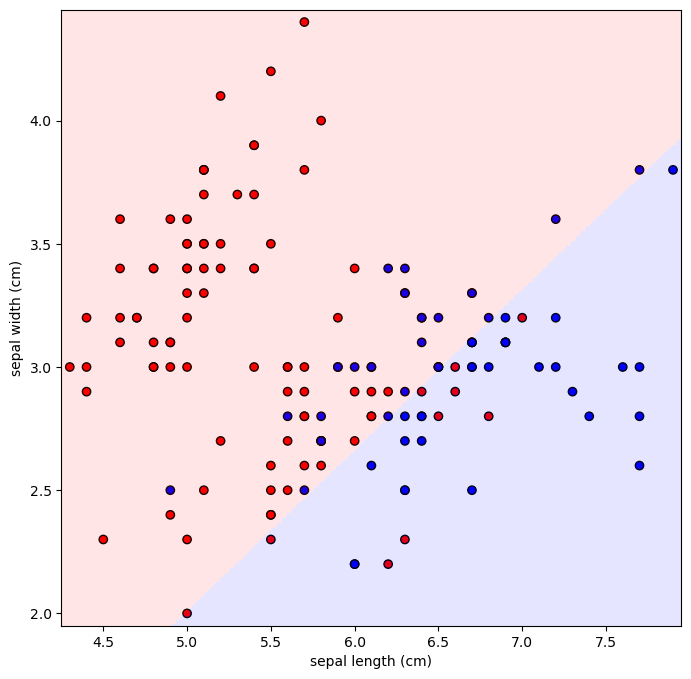

In [34]:
featureX = 'sepal length (cm)'
featureY = 'sepal width (cm)'

X_2 = X[[featureX,featureY]]
clf = LogisticRegression(solver='liblinear')
clf.fit(X_2,y_1)
plt.figure(figsize=(8, 8))
hp.featureSpacePlot(featureX,featureY,X,y_1,clf,plt);

The boundary is a straight line

We now use two different features

c:\Users\33659\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


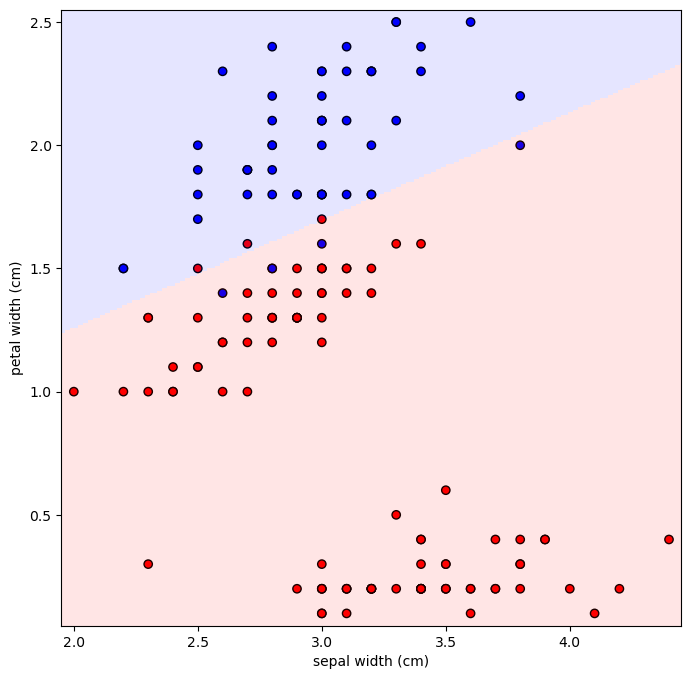

In [37]:
featureX = 'sepal width (cm)'
featureY = 'petal width (cm)'

X_2 = X[[featureX,featureY]]
clf = LogisticRegression(solver='liblinear')
clf.fit(X_2,y_1)
plt.figure(figsize=(8, 8))
hp.featureSpacePlot(featureX,featureY,X,y_1,clf,plt);

This looks much better - we can see that the points can be separated by a straight line.